In [1]:
import pandas as pd

df = pd.read_csv("house_prices.csv")
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [2]:
import pandas as pd

df['Price (in rupees)'] = pd.to_numeric(
    df['Price (in rupees)'].astype(str).str.replace(',', '', regex=False),
    errors='coerce'
)

def extract_number(series):
    return pd.to_numeric(
        series.astype(str).str.extract(r'(\d+(?:\.\d+)?)')[0],
        errors='coerce'
    )

df['Carpet Area'] = extract_number(df['Carpet Area'])
df['Super Area']  = extract_number(df['Super Area'])
df['Bathroom']    = extract_number(df['Bathroom'])

In [3]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression

df['Price_per_Sqft'] = df['Price (in rupees)'] / df['Carpet Area']
df.loc[df['Carpet Area'].isna() | (df['Carpet Area'] == 0), 'Price_per_Sqft'] = np.nan

X = df[['Carpet Area', 'Super Area', 'Bathroom', 'Price_per_Sqft']]
y = df['Price (in rupees)']

mask = y.notna()
X = X[mask]
y = y[mask]

imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(X)

selector = SelectKBest(score_func=f_regression, k=3)
X_selected = selector.fit_transform(X_imp, y)

selected_features = X.columns[selector.get_support()]
selected_scores = selector.scores_[selector.get_support()]

print("Selected features:", list(selected_features))
print("Scores:", list(selected_scores))

Selected features: ['Super Area', 'Bathroom', 'Price_per_Sqft']
Scores: [np.float64(33.457392744924796), np.float64(643.2945646129662), np.float64(33376.45034726785)]


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 22 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  float64
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  float64
 15  Balcony            138596 non-null  object 
 16  Ca

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df = df.drop(columns=['Plot Area', 'Dimensions'])

In [7]:
num_cols = ['Price (in rupees)', 'Carpet Area', 'Super Area', 'Bathroom']

In [8]:
df[num_cols].dtypes

Price (in rupees)    float64
Carpet Area          float64
Super Area           float64
Bathroom             float64
dtype: object

In [9]:
df['Price_per_Sqft'] = df['Price (in rupees)'] / df['Carpet Area']

In [10]:
median_price = df['Price (in rupees)'].median()

df['is_luxury'] = (df['Price (in rupees)'] > median_price).astype(int)

In [11]:
top_k = 10
top_locations = df['location'].value_counts().head(top_k).index

df['location_reduced'] = df['location'].apply(
    lambda x: x if x in top_locations else 'Other'
)

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score

features = ['Carpet Area', 'Super Area', 'Bathroom', 'Price_per_Sqft']
X = df[features]
y = df['Price (in rupees)']

mask = y.notna()
X = X[mask]
y = y[mask]

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

baseline_r2 = r2_score(y_test, model.predict(X_test))
print("Baseline R2:", baseline_r2)

Baseline R2: 0.39829534346180895


In [13]:
import numpy as np
import pandas as pd

def to_number(series):
    return pd.to_numeric(series.astype(str).str.extract(r'(\d+(?:\.\d+)?)')[0], errors='coerce')

df['Bathroom'] = to_number(df['Bathroom'])
df['Balcony'] = to_number(df['Balcony'])
df['Carpet Area'] = to_number(df['Carpet Area'])
df['Super Area'] = to_number(df['Super Area'])

In [14]:
df['Price_per_Sqft'] = df['Price (in rupees)'] / df['Carpet Area']
df.loc[df['Carpet Area'].isna() | (df['Carpet Area'] == 0), 'Price_per_Sqft'] = np.nan

In [15]:
median_price = df['Price (in rupees)'].median()
df['High_Price'] = (df['Price (in rupees)'] > median_price).astype(int)

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

df['Price_per_Sqft'] = df['Price (in rupees)'] / df['Carpet Area']
df.loc[df['Carpet Area'].isna() | (df['Carpet Area'] == 0), 'Price_per_Sqft'] = np.nan

target = 'High_Price'

num_features = ['Carpet Area', 'Super Area', 'Bathroom', 'Balcony', 'Price_per_Sqft']
cat_features = ['Furnishing', 'Transaction', 'Ownership', 'Status', 'facing', 'overlooking', 'location']

use_cols = num_features + cat_features + [target]
data = df[use_cols].copy()

data = data.dropna(subset=[target])

X = data.drop(columns=[target])
y = data[target]

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

target = 'High_Price'

num_features = ['Carpet Area', 'Super Area', 'Bathroom', 'Balcony', 'Price_per_Sqft']
cat_features = ['Furnishing', 'Transaction', 'Ownership', 'Status', 'facing', 'overlooking', 'location']

data = df[num_features + cat_features + [target]].copy()
data = data.dropna(subset=[target])

X = data.drop(columns=[target])
y = data[target]

num_imputer = SimpleImputer(strategy='median')
X[num_features] = num_imputer.fit_transform(X[num_features])

cat_imputer = SimpleImputer(strategy='most_frequent')
X[cat_features] = cat_imputer.fit_transform(X[cat_features])

X_encoded = pd.get_dummies(X, columns=cat_features, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)

Accuracy: 0.9556616098328312


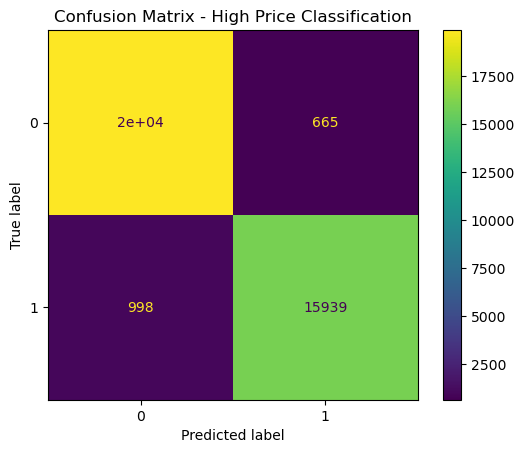

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)
plt.title("Confusion Matrix - High Price Classification")
plt.show()

In [20]:
import pandas as pd

top_n = 15

feature_names = X_encoded.columns
importances = clf.feature_importances_

fi = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print(fi.head(top_n))

                      feature  importance
1                  Super Area    0.180366
4              Price_per_Sqft    0.168375
0                 Carpet Area    0.128420
2                    Bathroom    0.066242
3                     Balcony    0.048744
60           location_gurgaon    0.040818
87         location_new-delhi    0.038944
26      overlooking_Main Road    0.033017
43         location_bangalore    0.020441
6      Furnishing_Unfurnished    0.019543
9          Transaction_Resale    0.017907
5   Furnishing_Semi-Furnished    0.017904
13               facing_North    0.017902
14        facing_North - East    0.014100
73           location_kolkata    0.013488


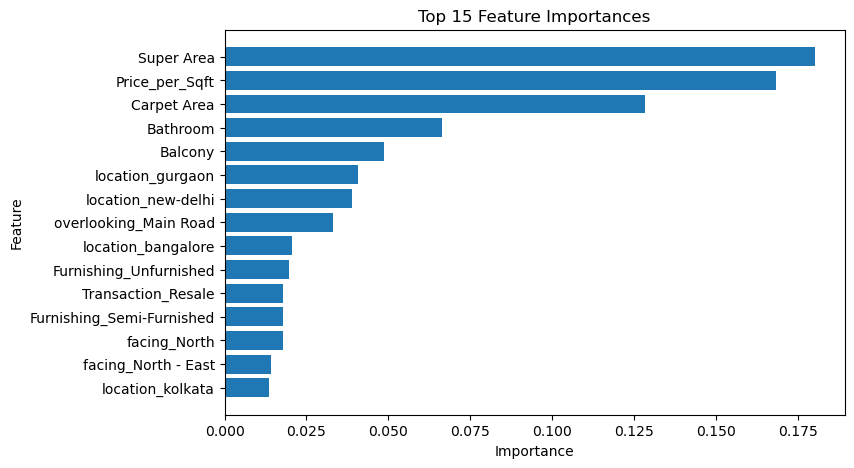

In [21]:
plt.figure(figsize=(8,5))
plt.barh(fi.head(top_n)["feature"][::-1], fi.head(top_n)["importance"][::-1])
plt.title(f"Top {top_n} Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()